In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
hd = pd.read_csv('housing.csv')
hd.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
hd.isna().sum() ## removing null values would just remove 1%  of data
#hd.dropna(inplace=True)

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

<Axes: >

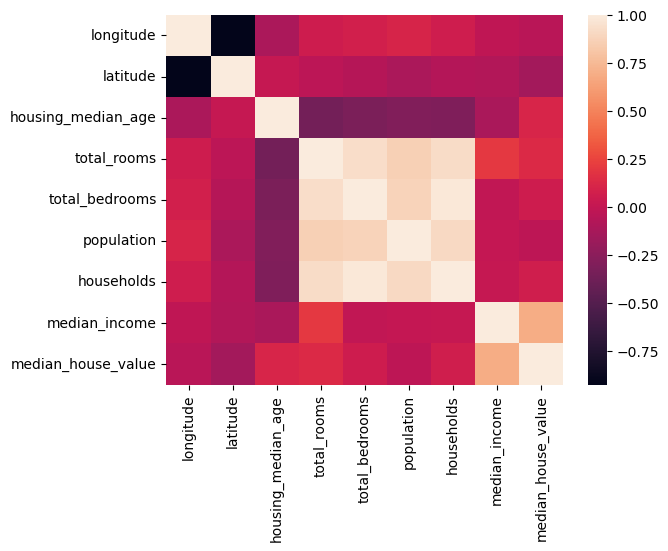

In [7]:
sns.heatmap(hd.drop(columns=['ocean_proximity']).corr())

In [10]:
### encode categorical column first:
hd.ocean_proximity.unique()
hd1 = pd.get_dummies(hd)
hd1.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [23]:
hd = hd1.copy()
hd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20433 non-null  float64
 1   latitude                    20433 non-null  float64
 2   housing_median_age          20433 non-null  float64
 3   total_rooms                 20433 non-null  float64
 4   total_bedrooms              20433 non-null  float64
 5   population                  20433 non-null  float64
 6   households                  20433 non-null  float64
 7   median_income               20433 non-null  float64
 8   median_house_value          20433 non-null  float64
 9   ocean_proximity_<1H OCEAN   20433 non-null  bool   
 10  ocean_proximity_INLAND      20433 non-null  bool   
 11  ocean_proximity_ISLAND      20433 non-null  bool   
 12  ocean_proximity_NEAR BAY    20433 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  20433 no

In [13]:
from sklearn.pipeline import Pipeline

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import root_mean_squared_error , r2_score



2.	Apply Lasso Regression and tune the regularization parameter α using cross-validation.

3.	Identify which features get reduced to zero.

4.	Apply Ridge Regression to the same dataset.

5.	Compare the coefficients with those from Lasso and Linear Regression.

6.	Discuss how Ridge helps in reducing overfitting.

7.	Plot the change in coefficients as α increases for both Lasso and Ridge Regression.

In [24]:
standard = StandardScaler()


In [28]:
# Get feature names for later analysis
#feature_names = X.columns.tolist()
print(feature_names)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [29]:

X = hd.drop('median_house_value', axis=1)
y = hd['median_house_value']

X = standard.fit_transform(X)
#yscale = standard.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [33]:
#lasso_pipeline = Pipeline([('scale',StandardScaler()),('lasso',Lasso(random_state=42))])
lasso = Lasso(random_state=40)
param_grid_lasso = {'alpha': np.logspace(-4, 2, 50)}

lasso_grid = GridSearchCV(
    lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

best_alpha_lasso = lasso_grid.best_params_['alpha']
print(f"Best alpha for Lasso: {best_alpha_lasso:.6f}")
print(f"Best cross-validation score: {-lasso_grid.best_score_:.2f}")


Best alpha for Lasso: 75.431201
Best cross-validation score: 4732165858.03


In [37]:
best_lasso = lasso_grid.best_estimator_
lasso_coef = best_lasso.coef_

In [ ]:


zero_features = [feature_names[i] for i in range(len(feature_names)) if lasso_coef[i] == 0]
print(f"Number of features reduced to zero: {len(zero_features)}")
print("Features with zero coefficients:")
for feature in zero_features:
    print(f"  - {feature}")



=== FEATURES REDUCED TO ZERO IN LASSO ===
Number of features reduced to zero: 1
Features with zero coefficients:
  - ocean_proximity_<1H OCEAN


In [ ]:
ridge= Ridge(random_state=42)
param_grid_ridge = {'alpha': np.logspace(-2, 4, 50)}


ridge_grid = GridSearchCV(
    ridge, 
    param_grid_ridge, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)


best_alpha_ridge = ridge_grid.best_params_['alpha']
print(f"Best alpha for Ridge: {best_alpha_ridge:.6f}")
print(f"Best cross-validation score: {-ridge_grid.best_score_:.2f}")


best_ridge = ridge_grid.best_estimator_
ridge_coef = best_ridge.coef_


Best alpha for Ridge: 26.826958
Best cross-validation score: 4731705705.17
